In [1]:
# ============================
# Cell 1: Imports & config
# ============================

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

import joblib

# Config
TEST_SIZE = 0.2          # 20% of (time-ordered) data for test
RANDOM_STATE = 42        # for reproducibility

GAMES_PATH = "games.csv"
GAMES_DETAILS_PATH = "games_details.csv"
PLAYERS_PATH = "players.csv"
RANKING_PATH = "ranking.csv"
TEAMS_PATH = "teams.csv"


In [2]:
# ============================
# Cell 2: Load CSVs
# ============================

games = pd.read_csv(GAMES_PATH)
games_details = pd.read_csv(GAMES_DETAILS_PATH, low_memory=False)
players = pd.read_csv(PLAYERS_PATH)
ranking = pd.read_csv(RANKING_PATH)
teams = pd.read_csv(TEAMS_PATH)

print("games shape:", games.shape)
print("games_details shape:", games_details.shape)
print("players shape:", players.shape)
print("ranking shape:", ranking.shape)
print("teams shape:", teams.shape)

display(games.head())
display(games_details.head())
display(ranking.head())
display(players.head())
display(teams.head())


games shape: (26651, 21)
games_details shape: (668628, 29)
players shape: (7228, 4)
ranking shape: (210342, 13)
teams shape: (30, 14)


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,...,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,...,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,...,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1
3,2022-12-21,22200467,Final,1610612755,1610612765,2022,1610612755,113.0,0.441,0.909,...,27.0,49.0,1610612765,93.0,0.392,0.735,0.261,15.0,46.0,1
4,2022-12-21,22200468,Final,1610612737,1610612741,2022,1610612737,108.0,0.429,1.000,...,22.0,47.0,1610612741,110.0,0.500,0.773,0.292,20.0,47.0,0


,GAME_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_CITY,PLAYER_ID,PLAYER_NAME,NICKNAME,START_POSITION,COMMENT,MIN,...,OREB,DREB,REB,AST,STL,BLK,TO,PF,PTS,PLUS_MINUS
0,22200477,1610612759,SAS,San Antonio,1629641,Romeo Langford,Romeo,F,NaN,18:06,...,1.0,1.0,2.0,0.0,1.0,0.0,2.0,5.0,2.0,-2.0
1,22200477,1610612759,SAS,San Antonio,1631110,Jeremy Sochan,Jeremy,F,NaN,31:01,...,6.0,3.0,9.0,6.0,1.0,0.0,2.0,1.0,23.0,-14.0
2,22200477,1610612759,SAS,San Antonio,1627751,Jakob Poeltl,Jakob,C,NaN,21:42,...,1.0,3.0,4.0,1.0,1.0,0.0,2.0,4.0,13.0,-4.0
3,22200477,1610612759,SAS,San Antonio,1630170,Devin Vassell,Devin,G,NaN,30:20,...,0.0,9.0,9.0,5.0,3.0,0.0,2.0,1.0,10.0,-18.0
4,22200477,1610612759,SAS,San Antonio,1630200,Tre Jones,Tre,G,NaN,27:44,...,0.0,2.0,2.0,3.0,0.0,0.0,2.0,2.0,19.0,0.0


,TEAM_ID,LEAGUE_ID,SEASON_ID,STANDINGSDATE,CONFERENCE,TEAM,G,W,L,W_PCT,HOME_RECORD,ROAD_RECORD,RETURNTOPLAY
0,1610612743,0,22022,2022-12-22,West,Denver,30,19,11,0.633,10-3,9-8,NaN
1,1610612763,0,22022,2022-12-22,West,Memphis,30,19,11,0.633,13-2,6-9,NaN
2,1610612740,0,22022,2022-12-22,West,New Orleans,31,19,12,0.613,13-4,6-8,NaN
3,1610612756,0,22022,2022-12-22,West,Phoenix,32,19,13,0.594,14-4,5-9,NaN
4,1610612746,0,22022,2022-12-22,West,LA Clippers,33,19,14,0.576,11-7,8-7,NaN


,PLAYER_NAME,TEAM_ID,PLAYER_ID,SEASON
0,Royce O'Neale,1610612762,1626220,2019
1,Bojan Bogdanovic,1610612762,202711,2019
2,Rudy Gobert,1610612762,203497,2019
3,Donovan Mitchell,1610612762,1628378,2019
4,Mike Conley,1610612762,201144,2019


,LEAGUE_ID,TEAM_ID,MIN_YEAR,MAX_YEAR,ABBREVIATION,NICKNAME,YEARFOUNDED,CITY,ARENA,ARENACAPACITY,OWNER,GENERALMANAGER,HEADCOACH,DLEAGUEAFFILIATION
0,0,1610612737,1949,2019,ATL,Hawks,1949,Atlanta,State Farm Arena,18729.0,Tony Ressler,Travis Schlenk,Lloyd Pierce,Erie Bayhawks
1,0,1610612738,1946,2019,BOS,Celtics,1946,Boston,TD Garden,18624.0,Wyc Grousbeck,Danny Ainge,Brad Stevens,Maine Red Claws
2,0,1610612740,2002,2019,NOP,Pelicans,2002,New Orleans,Smoothie King Center,NaN,Tom Benson,Trajan Langdon,Alvin Gentry,No Affiliate
3,0,1610612741,1966,2019,CHI,Bulls,1966,Chicago,United Center,21711.0,Jerry Reinsdorf,Gar Forman,Jim Boylen,Windy City Bulls
4,0,1610612742,1980,2019,DAL,Mavericks,1980,Dallas,American Airlines Center,19200.0,Mark Cuban,Donnie Nelson,Rick Carlisle,Texas Legends


In [3]:
# ============================
# Cell 3: Date formatting & sort
# ============================

games["GAME_DATE_EST"] = pd.to_datetime(games["GAME_DATE_EST"])
ranking["STANDINGSDATE"] = pd.to_datetime(ranking["STANDINGSDATE"])

# Ensure games sorted in time order
games = games.sort_values(["GAME_DATE_EST", "GAME_ID"]).reset_index(drop=True)

print("Seasons in games:", sorted(games["SEASON"].unique()))


Seasons in games: [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [4]:
# ============================
# Cell 4: Team-game table from games.csv
# ============================

def build_team_game_table(games_df: pd.DataFrame) -> pd.DataFrame:
    # Home team rows
    home = games_df[[
        "GAME_ID", "GAME_DATE_EST", "SEASON",
        "HOME_TEAM_ID", "VISITOR_TEAM_ID",
        "PTS_home", "PTS_away",
        "FG_PCT_home", "FT_PCT_home", "FG3_PCT_home",
        "AST_home", "REB_home",
        "HOME_TEAM_WINS"
    ]].copy()

    home.rename(columns={
        "HOME_TEAM_ID": "TEAM_ID",
        "VISITOR_TEAM_ID": "OPPONENT_ID",
        "PTS_home": "PTS_FOR",
        "PTS_away": "PTS_AGAINST",
        "FG_PCT_home": "FG_PCT_FOR",
        "FT_PCT_home": "FT_PCT_FOR",
        "FG3_PCT_home": "FG3_PCT_FOR",
        "AST_home": "AST_FOR",
        "REB_home": "REB_FOR"
    }, inplace=True)

    home["IS_HOME"] = 1
    home["WIN"] = home["HOME_TEAM_WINS"]

    # Away team rows
    away = games_df[[
        "GAME_ID", "GAME_DATE_EST", "SEASON",
        "HOME_TEAM_ID", "VISITOR_TEAM_ID",
        "PTS_home", "PTS_away",
        "FG_PCT_away", "FT_PCT_away", "FG3_PCT_away",
        "AST_away", "REB_away",
        "HOME_TEAM_WINS"
    ]].copy()

    away.rename(columns={
        "VISITOR_TEAM_ID": "TEAM_ID",
        "HOME_TEAM_ID": "OPPONENT_ID",
        "PTS_away": "PTS_FOR",
        "PTS_home": "PTS_AGAINST",
        "FG_PCT_away": "FG_PCT_FOR",
        "FT_PCT_away": "FT_PCT_FOR",
        "FG3_PCT_away": "FG3_PCT_FOR",
        "AST_away": "AST_FOR",
        "REB_away": "REB_FOR"
    }, inplace=True)

    away["IS_HOME"] = 0
    away["WIN"] = 1 - away["HOME_TEAM_WINS"]

    team_games = pd.concat([home, away], ignore_index=True)
    return team_games


team_games = build_team_game_table(games)
print("team_games shape:", team_games.shape)
display(team_games.head())


team_games shape: (53302, 15)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_ID,PTS_FOR,PTS_AGAINST,FG_PCT_FOR,FT_PCT_FOR,FG3_PCT_FOR,AST_FOR,REB_FOR,HOME_TEAM_WINS,IS_HOME,WIN
0,10300001,2003-10-05,2003,1610612762,1610612742,90.0,85.0,0.457,0.735,0.143,23.0,41.0,1,1,1
1,10300002,2003-10-06,2003,1610612763,1610612749,105.0,94.0,0.494,0.618,0.267,25.0,48.0,1,1,1
2,10300003,2003-10-07,2003,1610612765,1610612739,96.0,100.0,0.391,0.600,0.444,19.0,37.0,0,1,0
3,10300004,2003-10-07,2003,1610612742,1610612753,99.0,89.0,0.488,0.667,0.167,20.0,52.0,1,1,1
4,10300005,2003-10-07,2003,1610612757,1610612745,104.0,80.0,0.527,0.657,0.429,22.0,33.0,1,1,1


In [5]:
# ============================
# Cell 5: Cumulative team features (all history)
# ============================

def add_cumulative_team_features(team_games_df: pd.DataFrame) -> pd.DataFrame:
    df = team_games_df.sort_values(["TEAM_ID", "GAME_DATE_EST"]).copy()

    def compute(group):
        group["team_cum_win_pct"] = group["WIN"].expanding().mean().shift(1)
        group["team_cum_pts_for"] = group["PTS_FOR"].expanding().mean().shift(1)
        group["team_cum_pts_against"] = group["PTS_AGAINST"].expanding().mean().shift(1)
        group["team_cum_ast_for"] = group["AST_FOR"].expanding().mean().shift(1)
        group["team_cum_reb_for"] = group["REB_FOR"].expanding().mean().shift(1)
        return group

    return df.groupby("TEAM_ID", group_keys=False).apply(compute)


team_games_cum = add_cumulative_team_features(team_games)
display(team_games_cum.head())


/var/folders/xq/wr32yg692fq_tlx130v92lvc0000gn/T/ipykernel_26196/1547858756.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("TEAM_ID", group_keys=False).apply(compute)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_ID,PTS_FOR,PTS_AGAINST,FG_PCT_FOR,FT_PCT_FOR,FG3_PCT_FOR,AST_FOR,REB_FOR,HOME_TEAM_WINS,IS_HOME,WIN,team_cum_win_pct,team_cum_pts_for,team_cum_pts_against,team_cum_ast_for,team_cum_reb_for
10,10300011,2003-10-08,2003,1610612737,1610612739,80.0,83.0,0.35,0.75,0.429,18.0,45.0,0,1,0,NaN,NaN,NaN,NaN,NaN
26673,10300023,2003-10-10,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0.000000,80.0,83.0,18.0,45.0
26690,10300042,2003-10-13,2003,1610612737,1610612750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0.500000,80.0,83.0,18.0,45.0
55,10300058,2003-10-16,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,0.666667,80.0,83.0,18.0,45.0
26721,10300073,2003-10-18,2003,1610612737,1610612763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0.500000,80.0,83.0,18.0,45.0


In [6]:
# ============================
# Cell 6: Player 'star power' features from games_details.csv
# ============================

# Attach game date & season to games_details
gd = games_details.merge(
    games[["GAME_ID", "GAME_DATE_EST", "SEASON"]],
    on="GAME_ID",
    how="left"
)
gd["GAME_DATE_EST"] = pd.to_datetime(gd["GAME_DATE_EST"])

def add_player_prior_avg_pts(gd_df: pd.DataFrame) -> pd.DataFrame:
    df = gd_df.sort_values(["PLAYER_ID", "GAME_DATE_EST"]).copy()

    def compute(group):
        # average points across all *previous* games (shift(1))
        group["player_prior_avg_pts"] = group["PTS"].expanding().mean().shift(1)
        return group

    return df.groupby("PLAYER_ID", group_keys=False).apply(compute)


gd_prior = add_player_prior_avg_pts(gd)

# Aggregate to team-game level: how strong is this roster based on past performance?
team_player_prior = gd_prior.groupby(["GAME_ID", "TEAM_ID"]).agg(
    team_star_power_sum=("player_prior_avg_pts", "sum"),
    team_star_power_max=("player_prior_avg_pts", "max"),
    team_star_power_mean=("player_prior_avg_pts", "mean"),
    num_players_with_history=("player_prior_avg_pts", lambda x: x.notna().sum())
).reset_index()

print("team_player_prior shape:", team_player_prior.shape)
display(team_player_prior.head())


/var/folders/xq/wr32yg692fq_tlx130v92lvc0000gn/T/ipykernel_26196/2834408282.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("PLAYER_ID", group_keys=False).apply(compute)


team_player_prior shape: (53047, 6)


,GAME_ID,TEAM_ID,team_star_power_sum,team_star_power_max,team_star_power_mean,num_players_with_history
0,10300001,1610612742,0.0,NaN,NaN,0
1,10300001,1610612762,0.0,NaN,NaN,0
2,10300002,1610612749,0.0,NaN,NaN,0
3,10300002,1610612763,0.0,NaN,NaN,0
4,10300003,1610612739,0.0,NaN,NaN,0


In [7]:
# ============================
# Cell 7: Merge team cumulative stats with player star power
# ============================

team_games_features = team_games_cum.merge(
    team_player_prior,
    on=["GAME_ID", "TEAM_ID"],
    how="left"
)

print("team_games_features shape:", team_games_features.shape)
display(team_games_features.head())


team_games_features shape: (53302, 24)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_ID,PTS_FOR,PTS_AGAINST,FG_PCT_FOR,FT_PCT_FOR,FG3_PCT_FOR,...,WIN,team_cum_win_pct,team_cum_pts_for,team_cum_pts_against,team_cum_ast_for,team_cum_reb_for,team_star_power_sum,team_star_power_max,team_star_power_mean,num_players_with_history
0,10300011,2003-10-08,2003,1610612737,1610612739,80.0,83.0,0.35,0.75,0.429,...,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
1,10300023,2003-10-10,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,...,1,0.000000,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN
2,10300042,2003-10-13,2003,1610612737,1610612750,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN
3,10300058,2003-10-16,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,...,0,0.666667,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN
4,10300073,2003-10-18,2003,1610612737,1610612763,NaN,NaN,NaN,NaN,NaN,...,1,0.500000,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN


In [8]:
# ============================
# Cell 8: Add ranking features (W_PCT, CONFERENCE)
# ============================

ranking_small = ranking[["TEAM_ID", "STANDINGSDATE", "W_PCT", "CONFERENCE"]].drop_duplicates()
ranking_small["STANDINGSDATE"] = pd.to_datetime(ranking_small["STANDINGSDATE"])

team_games_features["GAME_DATE_EST"] = pd.to_datetime(team_games_features["GAME_DATE_EST"])

team_games_rank = team_games_features.merge(
    ranking_small,
    left_on=["TEAM_ID", "GAME_DATE_EST"],
    right_on=["TEAM_ID", "STANDINGSDATE"],
    how="left"
).drop(columns=["STANDINGSDATE"])

print("team_games_rank shape:", team_games_rank.shape)
display(team_games_rank.head())


team_games_rank shape: (53321, 26)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_ID,PTS_FOR,PTS_AGAINST,FG_PCT_FOR,FT_PCT_FOR,FG3_PCT_FOR,...,team_cum_pts_for,team_cum_pts_against,team_cum_ast_for,team_cum_reb_for,team_star_power_sum,team_star_power_max,team_star_power_mean,num_players_with_history,W_PCT,CONFERENCE
0,10300011,2003-10-08,2003,1610612737,1610612739,80.0,83.0,0.35,0.75,0.429,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,East
1,10300023,2003-10-10,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,...,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN,0.0,East
2,10300042,2003-10-13,2003,1610612737,1610612750,NaN,NaN,NaN,NaN,NaN,...,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN,0.0,East
3,10300058,2003-10-16,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,...,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN,0.0,East
4,10300073,2003-10-18,2003,1610612737,1610612763,NaN,NaN,NaN,NaN,NaN,...,80.0,83.0,18.0,45.0,NaN,NaN,NaN,NaN,0.0,East


In [9]:
# ============================
# Cell 9: Add teams.csv + players.csv features
# ============================

# From teams.csv: YEARFOUNDED, ARENACAPACITY
teams_meta = teams[["TEAM_ID", "YEARFOUNDED", "ARENACAPACITY"]].copy()

team_games_full = team_games_rank.merge(teams_meta, on="TEAM_ID", how="left")

# From players.csv: number of registered players per team per season
players_team_season = players.groupby(["TEAM_ID", "SEASON"]).agg(
    num_registered_players=("PLAYER_ID", "nunique")
).reset_index()

team_games_full = team_games_full.merge(
    players_team_season,
    on=["TEAM_ID", "SEASON"],
    how="left"
)

print("team_games_full shape:", team_games_full.shape)
display(team_games_full.head())


team_games_full shape: (53321, 29)


,GAME_ID,GAME_DATE_EST,SEASON,TEAM_ID,OPPONENT_ID,PTS_FOR,PTS_AGAINST,FG_PCT_FOR,FT_PCT_FOR,FG3_PCT_FOR,...,team_cum_reb_for,team_star_power_sum,team_star_power_max,team_star_power_mean,num_players_with_history,W_PCT,CONFERENCE,YEARFOUNDED,ARENACAPACITY,num_registered_players
0,10300011,2003-10-08,2003,1610612737,1610612739,80.0,83.0,0.35,0.75,0.429,...,NaN,0.0,NaN,NaN,0.0,0.0,East,1949,18729.0,NaN
1,10300023,2003-10-10,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,...,45.0,NaN,NaN,NaN,NaN,0.0,East,1949,18729.0,NaN
2,10300042,2003-10-13,2003,1610612737,1610612750,NaN,NaN,NaN,NaN,NaN,...,45.0,NaN,NaN,NaN,NaN,0.0,East,1949,18729.0,NaN
3,10300058,2003-10-16,2003,1610612737,1610612748,NaN,NaN,NaN,NaN,NaN,...,45.0,NaN,NaN,NaN,NaN,0.0,East,1949,18729.0,NaN
4,10300073,2003-10-18,2003,1610612737,1610612763,NaN,NaN,NaN,NaN,NaN,...,45.0,NaN,NaN,NaN,NaN,0.0,East,1949,18729.0,NaN


In [10]:
# ============================
# Cell 10: Build game-level dataset with home/away features
# ============================

def build_game_level(team_df: pd.DataFrame, games_df: pd.DataFrame) -> pd.DataFrame:
    # Home side
    home = team_df[team_df["IS_HOME"] == 1].copy()
    # Away side
    away = team_df[team_df["IS_HOME"] == 0].copy()

    cols_to_use = [
        "GAME_ID",
        "team_cum_win_pct", "team_cum_pts_for", "team_cum_pts_against",
        "team_cum_ast_for", "team_cum_reb_for",
        "team_star_power_sum", "team_star_power_max", "team_star_power_mean",
        "num_players_with_history",
        "W_PCT", "CONFERENCE",
        "YEARFOUNDED", "ARENACAPACITY",
        "num_registered_players"
    ]

    home = home[cols_to_use].rename(columns=lambda c: "home_" + c if c != "GAME_ID" else c)
    away = away[cols_to_use].rename(columns=lambda c: "away_" + c if c != "GAME_ID" else c)

    df = games_df.merge(home, on="GAME_ID", how="inner").merge(away, on="GAME_ID", how="inner")
    return df


model_df = build_game_level(team_games_full, games)

print("model_df shape:", model_df.shape)
display(model_df.head())


model_df shape: (26887, 49)


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,away_team_cum_reb_for,away_team_star_power_sum,away_team_star_power_max,away_team_star_power_mean,away_num_players_with_history,away_W_PCT,away_CONFERENCE,away_YEARFOUNDED,away_ARENACAPACITY,away_num_registered_players
0,2003-10-05,10300001,Final,1610612762,1610612742,2003,1610612762,90.0,0.457,0.735,...,NaN,0.0,NaN,NaN,0.0,0.0,West,1980,19200.0,NaN
1,2003-10-06,10300002,Final,1610612763,1610612749,2003,1610612763,105.0,0.494,0.618,...,NaN,0.0,NaN,NaN,0.0,0.0,East,1968,17500.0,NaN
2,2003-10-07,10300003,Final,1610612765,1610612739,2003,1610612765,96.0,0.391,0.600,...,NaN,0.0,NaN,NaN,0.0,0.0,East,1970,20562.0,NaN
3,2003-10-07,10300004,Final,1610612742,1610612753,2003,1610612742,99.0,0.488,0.667,...,NaN,0.0,NaN,NaN,0.0,0.0,East,1989,0.0,NaN
4,2003-10-07,10300005,Final,1610612757,1610612745,2003,1610612757,104.0,0.527,0.657,...,NaN,0.0,NaN,NaN,0.0,0.0,West,1967,18104.0,NaN


In [11]:
# ============================
# Cell 11: Feature selection & train/test split
# ============================

# Features we will use
feature_cols = [
    "home_team_cum_win_pct", "home_team_cum_pts_for", "home_team_cum_pts_against",
    "home_team_cum_ast_for", "home_team_cum_reb_for",
    "away_team_cum_win_pct", "away_team_cum_pts_for", "away_team_cum_pts_against",
    "away_team_cum_ast_for", "away_team_cum_reb_for",
    "home_team_star_power_sum", "home_team_star_power_max", "home_team_star_power_mean",
    "home_num_players_with_history",
    "away_team_star_power_sum", "away_team_star_power_max", "away_team_star_power_mean",
    "away_num_players_with_history",
    "home_W_PCT", "away_W_PCT",
    "home_YEARFOUNDED", "home_ARENACAPACITY",
    "away_YEARFOUNDED", "away_ARENACAPACITY",
]

# Encode conference (from ranking) as binary flags
model_df["home_conf_is_west"] = (model_df["home_CONFERENCE"] == "West").astype(int)
model_df["away_conf_is_west"] = (model_df["away_CONFERENCE"] == "West").astype(int)
feature_cols += ["home_conf_is_west", "away_conf_is_west"]

# Drop rows with missing key features or labels
df_clean = model_df.dropna(subset=feature_cols + ["HOME_TEAM_WINS", "GAME_DATE_EST"]).copy()

# Sort chronologically to avoid future leakage
df_clean = df_clean.sort_values("GAME_DATE_EST").reset_index(drop=True)

X = df_clean[feature_cols].astype(float)
y = df_clean["HOME_TEAM_WINS"].astype(int)

n_samples = len(df_clean)
split_idx = int((1 - TEST_SIZE) * n_samples)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Total samples:", n_samples)
print("Train samples:", len(X_train))
print("Test samples:", len(X_test))


Total samples: 20035
Train samples: 16028
Test samples: 4007


In [12]:
# ============================
# Cell 12: Train RandomForest model
# ============================

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_clf.fit(X_train, y_train)
print("Model trained!")


Model trained!


Accuracy: 0.6960
ROC AUC:  0.7790

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.45      0.57      1785
           1       0.67      0.89      0.76      2222

    accuracy                           0.70      4007
   macro avg       0.72      0.67      0.67      4007
weighted avg       0.71      0.70      0.68      4007



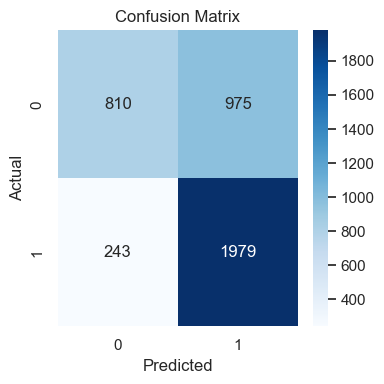

In [13]:
# ============================
# Cell 13: Evaluation
# ============================

y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


,feature,importance
18,home_W_PCT,0.148544
19,away_W_PCT,0.131787
0,home_team_cum_win_pct,0.043573
15,away_team_star_power_max,0.043075
5,away_team_cum_win_pct,0.042562
12,home_team_star_power_mean,0.042227
11,home_team_star_power_max,0.041573
16,away_team_star_power_mean,0.040987
14,away_team_star_power_sum,0.039523
3,home_team_cum_ast_for,0.038917


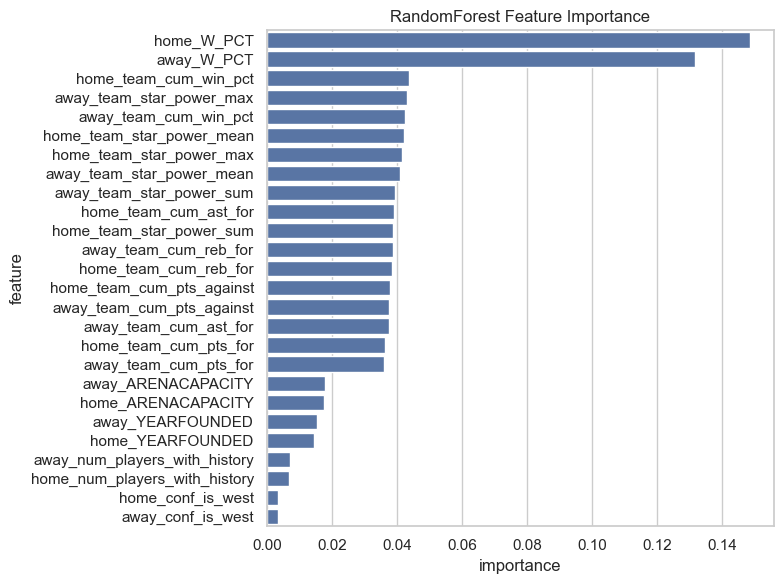

In [14]:
# ============================
# Cell 14: Feature importance
# ============================

importances = rf_clf.feature_importances_
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi)

plt.figure(figsize=(8, 6))
sns.barplot(data=fi, x="importance", y="feature")
plt.title("RandomForest Feature Importance")
plt.tight_layout()
plt.show()


In [15]:
# ============================
# Cell 15: Save trained model
# ============================

MODEL_PATH = "nba_winner_all_files_model.pkl"
joblib.dump(rf_clf, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to nba_winner_all_files_model.pkl


In [18]:
# ============================
# Step D: Add team names
# ============================

# Extract ID -> Team Name mapping
team_names_map = teams.set_index("TEAM_ID")["NICKNAME"].to_dict()

def get_team_name(team_id):
    return team_names_map.get(team_id, f"Team {team_id}")


In [19]:
# Updated Helper: predict by GAME_ID with team names

def predict_game_by_id(game_id, df_games_clean, model, feature_columns):
    row = df_games_clean[df_games_clean["GAME_ID"] == game_id]

    if row.empty:
        print(f"No game found with GAME_ID = {game_id}")
        return None

    row = row.iloc[0]
    X_row = row[feature_columns].astype(float).values.reshape(1, -1)

    proba_home_win = model.predict_proba(X_row)[0, 1]
    pred_label = model.predict(X_row)[0]

    home_id = row["HOME_TEAM_ID"]
    away_id = row["VISITOR_TEAM_ID"]

    print("========== Game Prediction ==========")
    print(f"GAME_ID: {game_id}")
    print(f"Date: {row['GAME_DATE_EST']}")
    print(f"Home: {get_team_name(home_id)} ({home_id})")
    print(f"Away: {get_team_name(away_id)} ({away_id})")
    print("-------------------------------------")
    print(f"Predicted home win probability: {proba_home_win:.3f}")
    print(f"Predicted: {'Home Win' if pred_label == 1 else 'Away Win'}")
    print(f"Actual: {'Home Win' if row['HOME_TEAM_WINS'] == 1 else 'Away Win'}")
    print("=====================================")

    return {
        "GAME_ID": game_id,
        "home_team": get_team_name(home_id),
        "away_team": get_team_name(away_id),
        "predicted_home_win_prob": proba_home_win,
        "predicted_label": int(pred_label),
        "actual_label": int(row["HOME_TEAM_WINS"]),
    }


In [22]:
# ============================
# Filter for Raptors 2018-19 season games
# ============================

RAPTORS_ID = 1610612761
TARGET_SEASON = 2018  # Raptors title season

raptors_games = df_clean[
    (
        (df_clean["HOME_TEAM_ID"] == RAPTORS_ID) |
        (df_clean["VISITOR_TEAM_ID"] == RAPTORS_ID)
    )
    & (df_clean["SEASON"] == TARGET_SEASON)
]

raptors_games = raptors_games.reset_index(drop=True)

print("Raptors 2018-19 games found:", len(raptors_games))
display(raptors_games.head())





Raptors 2018-19 games found: 89


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,away_team_star_power_max,away_team_star_power_mean,away_num_players_with_history,away_W_PCT,away_CONFERENCE,away_YEARFOUNDED,away_ARENACAPACITY,away_num_registered_players,home_conf_is_west,away_conf_is_west
0,2018-09-29,11800003,Final,1610612761,1610612757,2018,1610612761,122.0,0.415,0.824,...,22.936685,7.811205,15.0,0.0,West,1970,19980.0,21.0,0,1
1,2018-10-02,11800019,Final,1610612762,1610612761,2018,1610612762,105.0,0.434,0.714,...,16.176015,7.127484,19.0,0.5,East,1995,19800.0,25.0,1,0
2,2018-10-17,21800008,Final,1610612761,1610612739,2018,1610612761,116.0,0.489,0.600,...,17.773890,8.966025,13.0,0.0,East,1970,20562.0,33.0,0,0
3,2018-10-19,21800019,Final,1610612761,1610612738,2018,1610612761,113.0,0.467,0.737,...,21.842610,9.359669,13.0,0.5,East,1946,18624.0,24.0,0,0
4,2018-10-20,21800027,Final,1610612764,1610612761,2018,1610612764,113.0,0.416,0.813,...,14.235103,8.201309,13.0,1.0,East,1995,19800.0,25.0,0,0


In [23]:
# ============================
# Predict all Raptors games (2018-19)
# ============================

raptors_preds = []
for _, row in raptors_games.iterrows():
    game_id = row["GAME_ID"]
    result = predict_game_by_id(
        game_id,
        df_games_clean=df_clean,
        model=rf_clf,
        feature_columns=feature_cols
    )
    raptors_preds.append(result)

raptors_preds_df = pd.DataFrame(raptors_preds)

print("\nSample of Raptors predictions:")
display(raptors_preds_df.head())

print(f"\nTotal Raptors games evaluated: {len(raptors_preds_df)}")


/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

========== Game Prediction ==========
GAME_ID: 11800003
Date: 2018-09-29 00:00:00
Home: Raptors (1610612761)
Away: Trail Blazers (1610612757)
-------------------------------------
Predicted home win probability: 0.973
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 11800019
Date: 2018-10-02 00:00:00
Home: Jazz (1610612762)
Away: Raptors (1610612761)
-------------------------------------
Predicted home win probability: 0.963
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 21800008
Date: 2018-10-17 00:00:00
Home: Raptors (1610612761)
Away: Cavaliers (1610612739)
-------------------------------------
Predicted home win probability: 0.983
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 21800019
Date: 2018-10-19 00:00:00
Home: Raptors (1610612761)
Away: Celtics (1610612738)
-------------------------------------
Predicted home win probability: 0.973
Predicted: Home Win
Actual: Home Win

/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

========== Game Prediction ==========
GAME_ID: 21800041
Date: 2018-10-22 00:00:00
Home: Raptors (1610612761)
Away: Hornets (1610612766)
-------------------------------------
Predicted home win probability: 0.953
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 21800055
Date: 2018-10-24 00:00:00
Home: Raptors (1610612761)
Away: Timberwolves (1610612750)
-------------------------------------
Predicted home win probability: 0.977
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 21800069
Date: 2018-10-26 00:00:00
Home: Raptors (1610612761)
Away: Mavericks (1610612742)
-------------------------------------
Predicted home win probability: 0.963
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 21800092
Date: 2018-10-29 00:00:00
Home: Bucks (1610612749)
Away: Raptors (1610612761)
-------------------------------------
Predicted home win probability: 0.870
Predicted: Home Win
Actual: Home Win

/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

...

/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

========== Game Prediction ==========
GAME_ID: 41800305
Date: 2019-05-23 00:00:00
Home: Bucks (1610612749)
Away: Raptors (1610612761)
-------------------------------------
Predicted home win probability: 0.627
Predicted: Home Win
Actual: Away Win
========== Game Prediction ==========
GAME_ID: 41800306
Date: 2019-05-25 00:00:00
Home: Raptors (1610612761)
Away: Bucks (1610612749)
-------------------------------------
Predicted home win probability: 0.580
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 41800401
Date: 2019-05-30 00:00:00
Home: Raptors (1610612761)
Away: Warriors (1610612744)
-------------------------------------
Predicted home win probability: 0.553
Predicted: Home Win
Actual: Home Win
========== Game Prediction ==========
GAME_ID: 41800402
Date: 2019-06-02 00:00:00
Home: Raptors (1610612761)
Away: Warriors (1610612744)
-------------------------------------
Predicted home win probability: 0.510
Predicted: Home Win
Actual: Away Win
======

/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/waleed/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

,GAME_ID,home_team,away_team,predicted_home_win_prob,predicted_label,actual_label
0,11800003,Raptors,Trail Blazers,0.973333,1,1
1,11800019,Jazz,Raptors,0.963333,1,1
2,21800008,Raptors,Cavaliers,0.983333,1,1
3,21800019,Raptors,Celtics,0.973333,1,1
4,21800027,Wizards,Raptors,0.043333,0,0



Total Raptors games evaluated: 89


Raptors-Only Accuracy: 0.8202
Raptors-Only ROC AUC: 0.9192

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.69      0.77        39
           1       0.79      0.92      0.85        50

    accuracy                           0.82        89
   macro avg       0.83      0.81      0.81        89
weighted avg       0.83      0.82      0.82        89



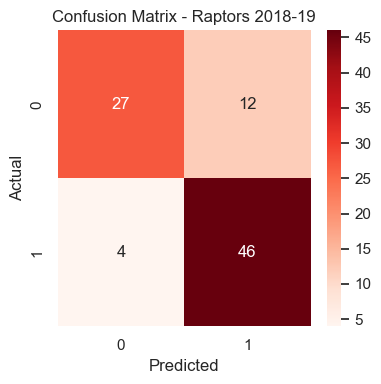

In [24]:
# ============================
# Evaluation: Raptors only
# ============================

y_pred_r = raptors_preds_df["predicted_label"]
y_true_r = raptors_preds_df["actual_label"]

acc_r = accuracy_score(y_true_r, y_pred_r)
auc_r = roc_auc_score(y_true_r, raptors_preds_df["predicted_home_win_prob"])

print(f"Raptors-Only Accuracy: {acc_r:.4f}")
print(f"Raptors-Only ROC AUC: {auc_r:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_r, y_pred_r))

cm_r = confusion_matrix(y_true_r, y_pred_r)
plt.figure(figsize=(4,4))
sns.heatmap(cm_r, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Raptors 2018-19")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
